### 01 - GTSRB Dataset Exploration

This notebook explores the structure, class distribution, image dimensions and sample images of the GTSRB dataset.

The main objectives are to:

- inspect the dataset structure;
- examine the number of images and classes;
- analyse class distribution;
- inspect sample images;
- analyse image dimensions;
- check for missing or corrupted files;
- summarise the main findings before preprocessing.

In [16]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

#### 1. Define Project Paths

Relative paths are used so that the project can be moved to another computer without changing the code.

In [17]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

TRAIN_CSV_PATH = DATA_DIR / "Train.csv"
TEST_CSV_PATH = DATA_DIR / "Test.csv"
META_CSV_PATH = DATA_DIR / "Meta.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Figures directory:", FIGURES_DIR.resolve())

Project root: /Users/liuyuhan/Desktop/traffic_recognition
Data directory: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive
Data directory exists: True
Figures directory: /Users/liuyuhan/Desktop/traffic_recognition/results/figures


In [18]:
required_files = [
    TRAIN_CSV_PATH,
    TEST_CSV_PATH,
    META_CSV_PATH
]

for file_path in required_files:
    print(f"{file_path.name}: {file_path.exists()}")

Train.csv: True
Test.csv: True
Meta.csv: True


#### 2. Load Dataset Metadata

The CSV files contain image dimensions, class labels, region-of-interest coordinates and image paths.

In [19]:
train_csv = pd.read_csv(TRAIN_CSV_PATH)
test_csv = pd.read_csv(TEST_CSV_PATH)
meta_csv = pd.read_csv(META_CSV_PATH)

print("Training CSV shape:", train_csv.shape)
print("Test CSV shape:", test_csv.shape)
print("Meta CSV shape:", meta_csv.shape)

Training CSV shape: (39209, 8)
Test CSV shape: (12630, 8)
Meta CSV shape: (43, 5)


In [21]:
print("Training data:")
display(train_csv.head())

print("Test data:")
display(test_csv.head())

print("Meta data:")
display(meta_csv.head())

Training data:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


Test data:


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


Meta data:


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


In [22]:
print("Training columns:")
print(train_csv.columns.tolist())

print("\nTraining data types:")
print(train_csv.dtypes)

Training columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

Training data types:
Width       int64
Height      int64
Roi.X1      int64
Roi.Y1      int64
Roi.X2      int64
Roi.Y2      int64
ClassId     int64
Path       object
dtype: object


In [23]:
print("Missing values in the training CSV:")
display(train_csv.isnull().sum())

print("Missing values in the test CSV:")
display(test_csv.isnull().sum())

Missing values in the training CSV:


Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64

Missing values in the test CSV:


Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64

In [24]:
print("Duplicate rows in training data:", train_csv.duplicated().sum())
print("Duplicate rows in test data:", test_csv.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


#### 3. Dataset Size and Number of Classes

This section reports the number of training images, test images and traffic sign classes.

In [25]:
number_of_training_images = len(train_csv)
number_of_test_images = len(test_csv)
number_of_classes = train_csv["ClassId"].nunique()

print("Number of training images:", number_of_training_images)
print("Number of test images:", number_of_test_images)
print("Number of classes:", number_of_classes)

print("\nMinimum training class ID:", train_csv["ClassId"].min())
print("Maximum training class ID:", train_csv["ClassId"].max())

print("Minimum test class ID:", test_csv["ClassId"].min())
print("Maximum test class ID:", test_csv["ClassId"].max())

Number of training images: 39209
Number of test images: 12630
Number of classes: 43

Minimum training class ID: 0
Maximum training class ID: 42
Minimum test class ID: 0
Maximum test class ID: 42


In [26]:
expected_class_ids = set(range(number_of_classes))
training_class_ids = set(train_csv["ClassId"].unique())
test_class_ids = set(test_csv["ClassId"].unique())

missing_training_classes = expected_class_ids - training_class_ids
missing_test_classes = expected_class_ids - test_class_ids

print("Missing classes in training set:", missing_training_classes)
print("Missing classes in test set:", missing_test_classes)

Missing classes in training set: set()
Missing classes in test set: set()


#### 4. Class Distribution

The number of images differs across traffic sign classes. 

Analysing class distribution to identify class imbalance.

In [27]:
class_counts = (
    train_csv["ClassId"]
    .value_counts()
    .sort_index()
)

class_distribution_df = pd.DataFrame({
    "ClassId": class_counts.index,
    "NumberOfImages": class_counts.values
})

display(class_distribution_df)

,ClassId,NumberOfImages
0,0,210
1,1,2220
2,2,2250
3,3,1410
4,4,1980
5,5,1860
6,6,420
7,7,1440
8,8,1410
9,9,1470


In [28]:
print("Smallest class size:", class_counts.min())
print("Largest class size:", class_counts.max())
print("Mean class size:", round(class_counts.mean(), 2))
print("Median class size:", class_counts.median())
print("Standard deviation:", round(class_counts.std(), 2))

print("\nFive smallest classes:")
display(class_counts.nsmallest(5).rename("NumberOfImages"))

print("\nFive largest classes:")
display(class_counts.nlargest(5).rename("NumberOfImages"))

Smallest class size: 210
Largest class size: 2250
Mean class size: 911.84
Median class size: 600.0
Standard deviation: 695.86

Five smallest classes:


0     210
19    210
37    210
27    240
32    240
Name: NumberOfImages, dtype: int64


Five largest classes:


2     2250
1     2220
13    2160
12    2100
38    2070
Name: NumberOfImages, dtype: int64

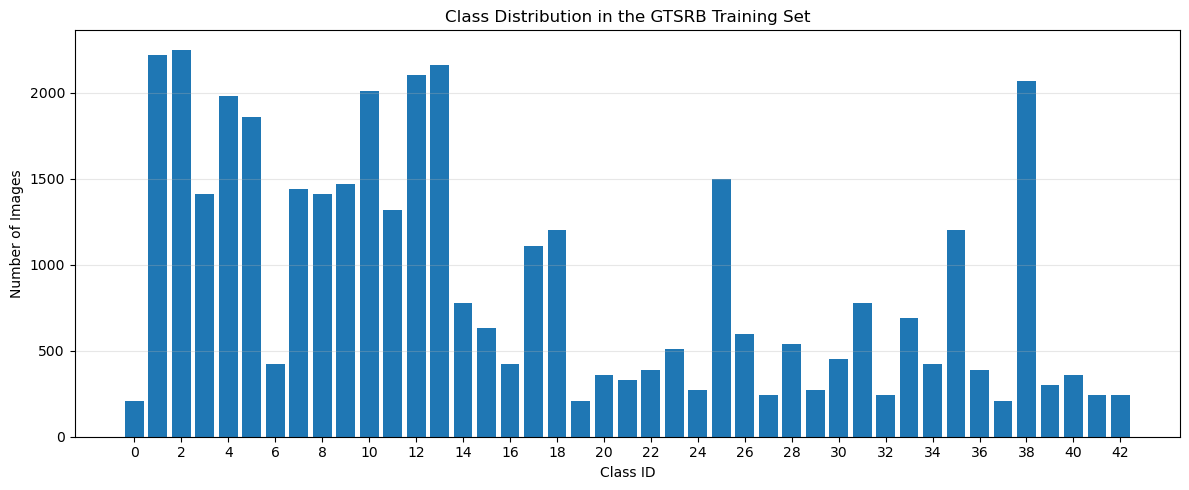

In [29]:
plt.figure(figsize=(12, 5))

plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribution in the GTSRB Training Set")
plt.xticks(range(0, number_of_classes, 2))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
class_proportions = (train_csv["ClassId"].value_counts(normalize=True).sort_index())

class_proportion_df = pd.DataFrame({
    "ClassId": class_proportions.index,
    "Proportion": class_proportions.values,
    "Percentage": class_proportions.values * 100
})

display(class_proportion_df.head())

,ClassId,Proportion,Percentage
0,0,0.005356,0.535591
1,1,0.056620,5.661965
2,2,0.057385,5.738478
3,3,0.035961,3.596113
4,4,0.050499,5.049861


#### 5. Sample Images

Random images are displayed to inspect image quality, lighting conditions, viewpoints and visual differences between classes.

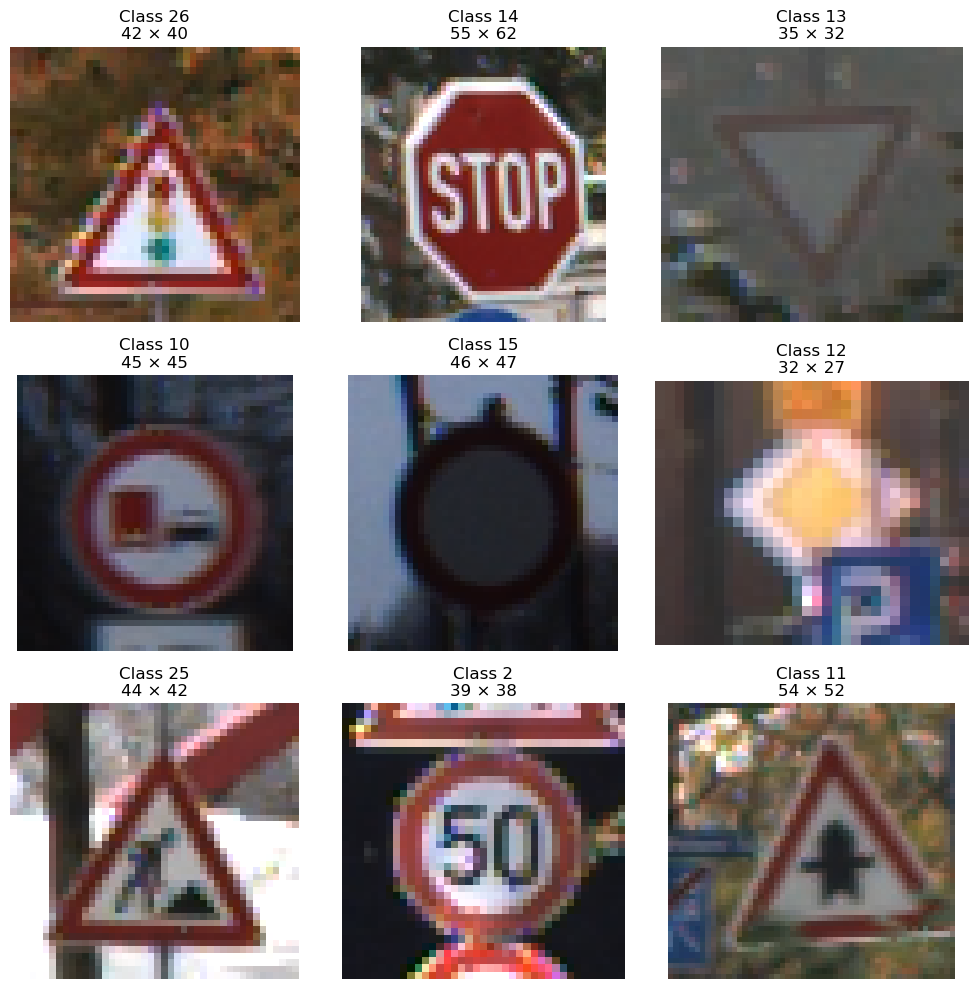

In [31]:
sample_rows = train_csv.sample(n=9, random_state=42)

plt.figure(figsize=(10, 10))

for plot_index, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    image_path = DATA_DIR / row["Path"]

    with Image.open(image_path) as image:
        image = image.convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(image)
        plt.title(
            f"Class {row['ClassId']}\n"
            f"{row['Width']} × {row['Height']}"
        )
        plt.axis("off")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "random_sample_images.png", dpi=300, bbox_inches="tight")

plt.show()

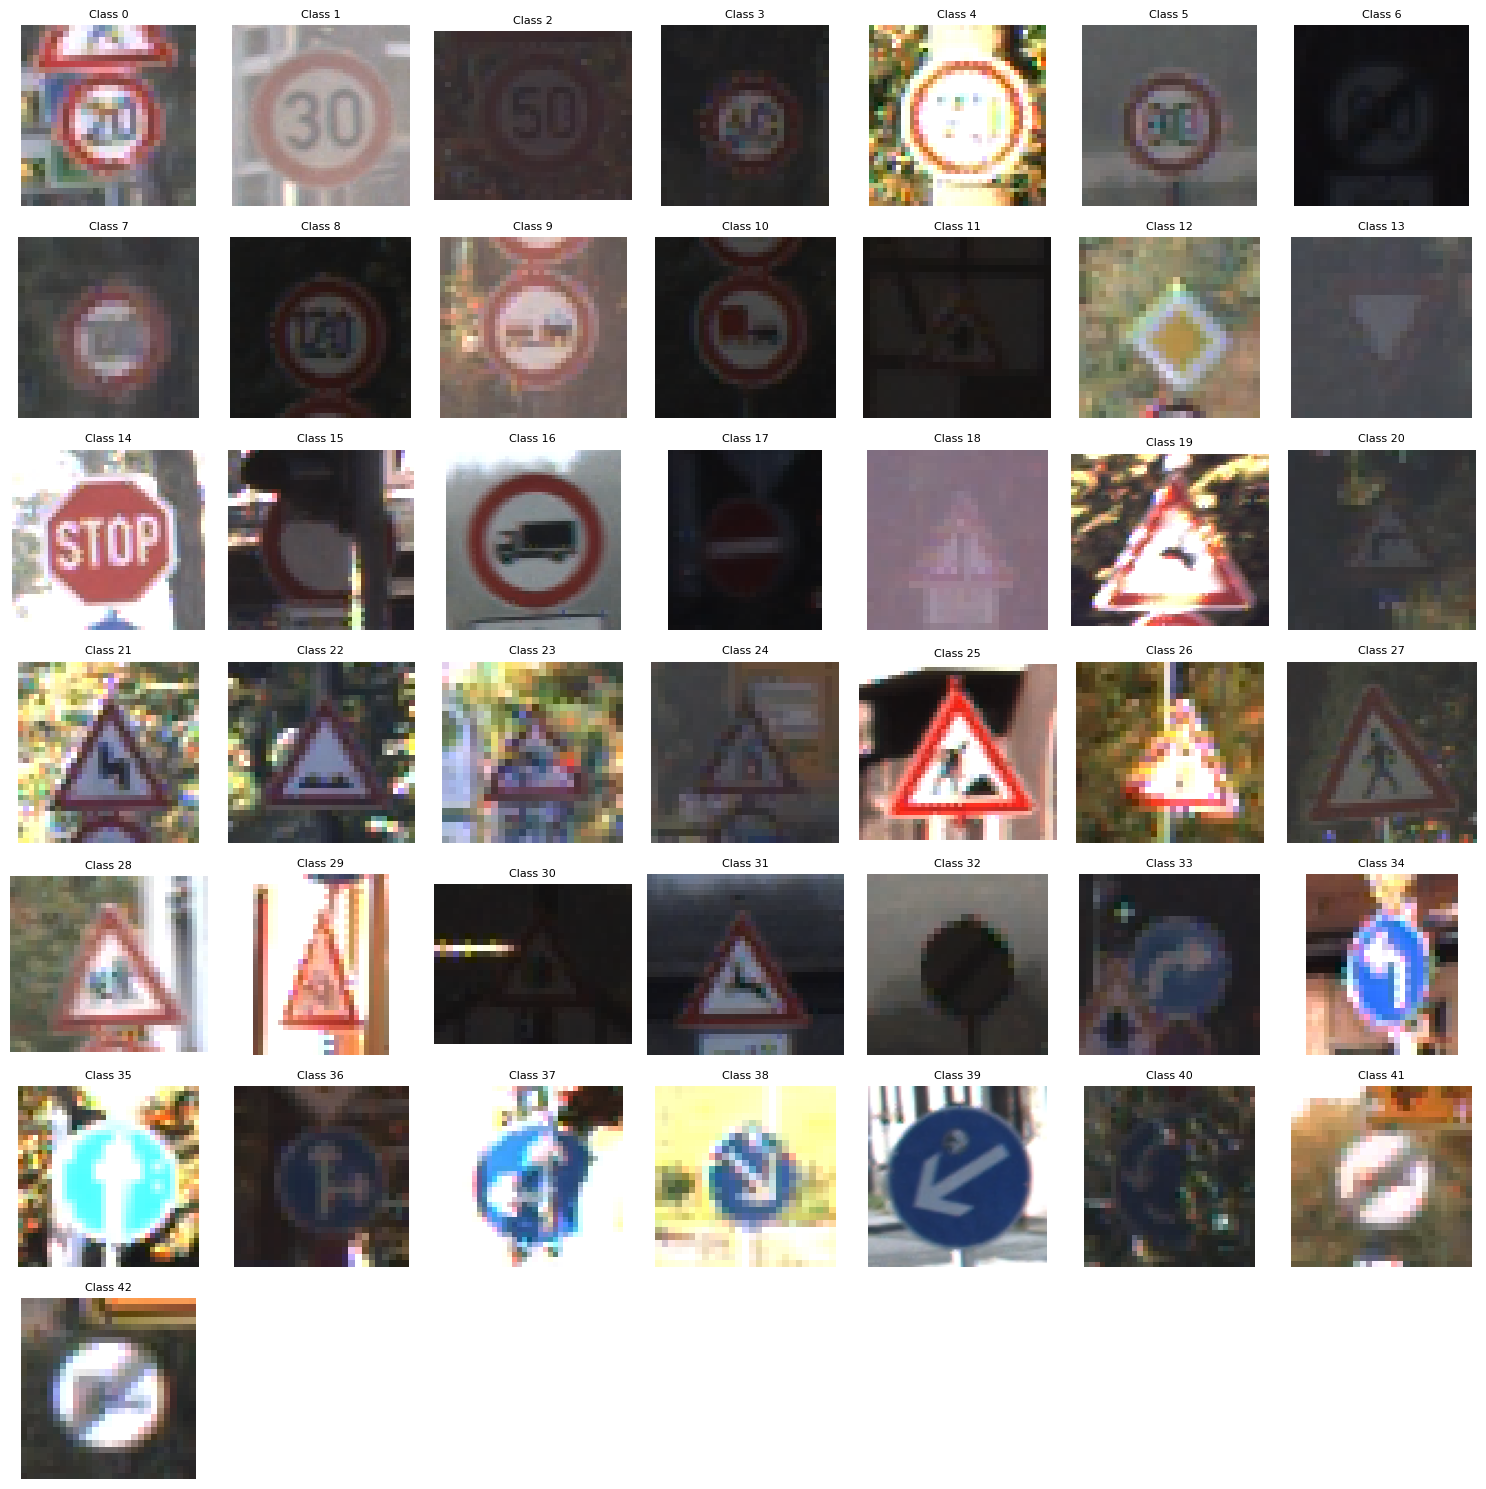

In [32]:
class_samples = (train_csv.groupby("ClassId", as_index=False).first().sort_values("ClassId"))

plt.figure(figsize=(15, 15))

for plot_index, (_, row) in enumerate(class_samples.iterrows(), start=1):
    image_path = DATA_DIR / row["Path"]

    with Image.open(image_path) as image:
        image = image.convert("RGB")

        plt.subplot(7, 7, plot_index)
        plt.imshow(image)
        plt.title(f"Class {row['ClassId']}",fontsize=8)
        plt.axis("off")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "one_sample_per_class.png", dpi=300, bbox_inches="tight")

plt.show()

#### 6. Image Size Analysis

The GTSRB images have different widths and heights, this variation must be addressed before model training.

In [33]:
print("Width statistics:")
display(train_csv["Width"].describe())

print("Height statistics:")
display(train_csv["Height"].describe())

print("Minimum width:", train_csv["Width"].min())
print("Maximum width:", train_csv["Width"].max())
print("Mean width:", round(train_csv["Width"].mean(), 2))

print("\nMinimum height:", train_csv["Height"].min())
print("Maximum height:", train_csv["Height"].max())
print("Mean height:", round(train_csv["Height"].mean(), 2))

Width statistics:


count    39209.000000
mean        50.835880
std         24.306933
min         25.000000
25%         35.000000
50%         43.000000
75%         58.000000
max        243.000000
Name: Width, dtype: float64

Height statistics:


count    39209.000000
mean        50.328930
std         23.115423
min         25.000000
25%         35.000000
50%         43.000000
75%         58.000000
max        225.000000
Name: Height, dtype: float64

Minimum width: 25
Maximum width: 243
Mean width: 50.84

Minimum height: 25
Maximum height: 225
Mean height: 50.33


In [34]:
train_csv = train_csv.copy()

train_csv["AspectRatio"] = (train_csv["Width"] / train_csv["Height"])

print("Aspect ratio statistics:")
display(train_csv["AspectRatio"].describe())

Aspect ratio statistics:


count    39209.000000
mean         1.007442
std          0.070825
min          0.368132
25%          0.971429
50%          1.000000
75%          1.040816
max          1.417808
Name: AspectRatio, dtype: float64

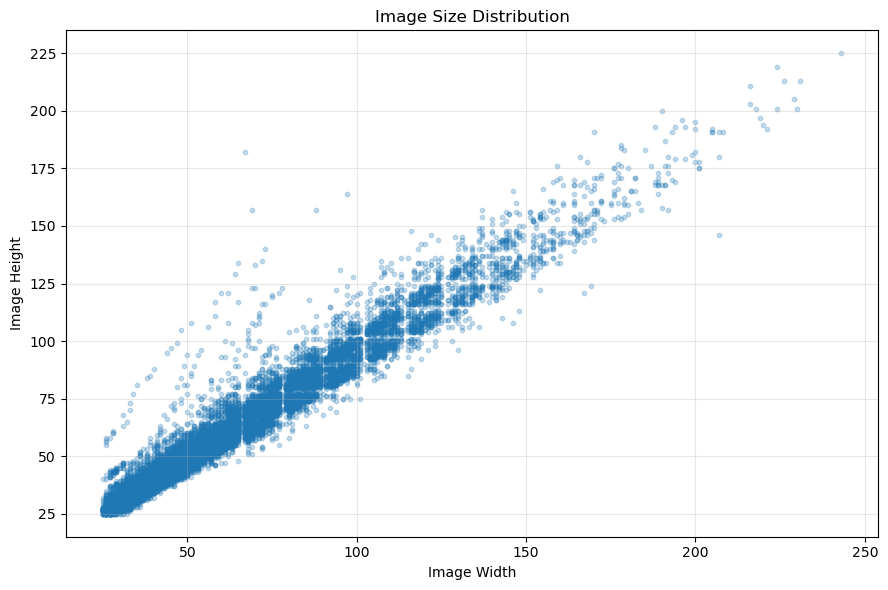

In [35]:
plt.figure(figsize=(9, 6))

plt.scatter(train_csv["Width"], train_csv["Height"], alpha=0.25, s=10)

plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("Image Size Distribution")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "image_size_scatter.png", dpi=300, bbox_inches="tight")

plt.show()

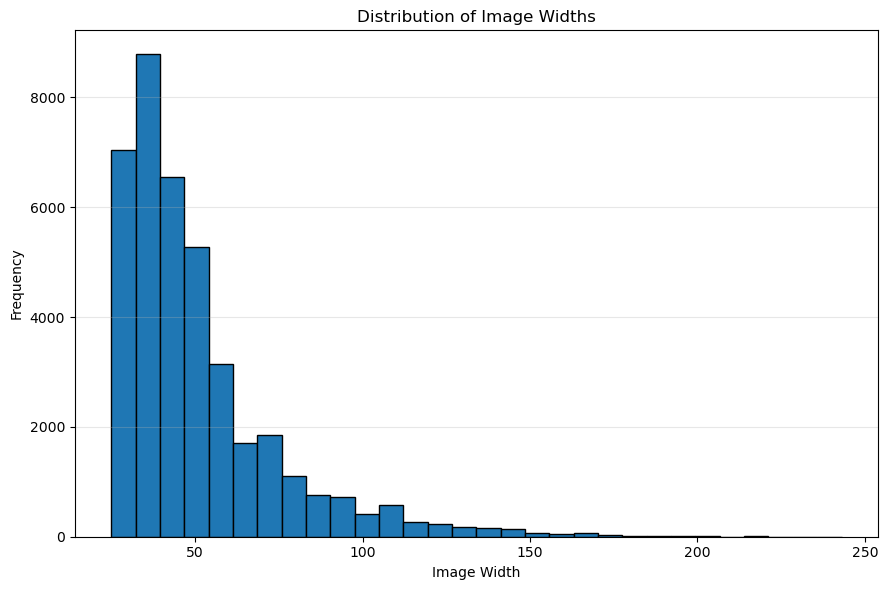

In [36]:
plt.figure(figsize=(9, 6))

plt.hist(train_csv["Width"], bins=30, edgecolor="black")

plt.xlabel("Image Width")
plt.ylabel("Frequency")
plt.title("Distribution of Image Widths")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "image_width_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

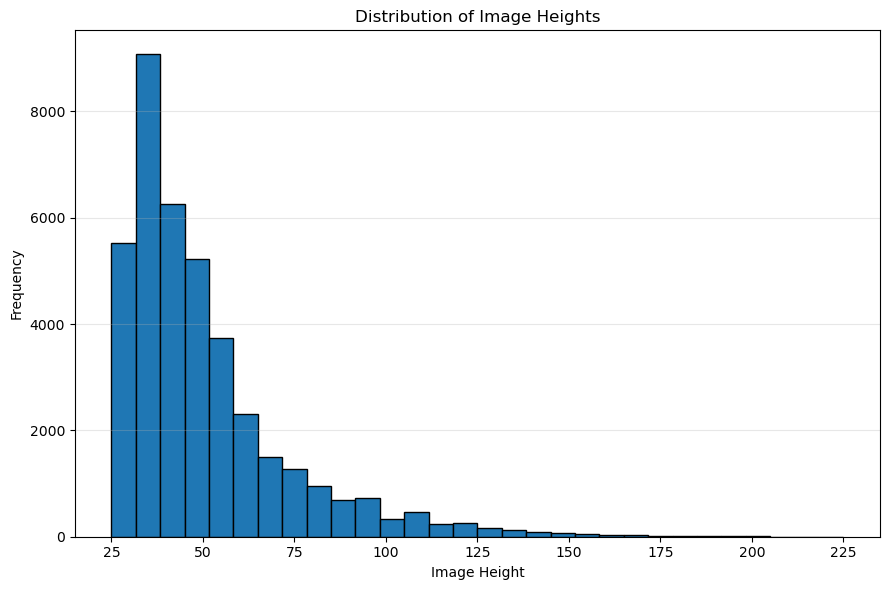

In [37]:
plt.figure(figsize=(9, 6))

plt.hist(train_csv["Height"], bins=30, edgecolor="black")

plt.xlabel("Image Height")
plt.ylabel("Frequency")
plt.title("Distribution of Image Heights")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "image_height_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

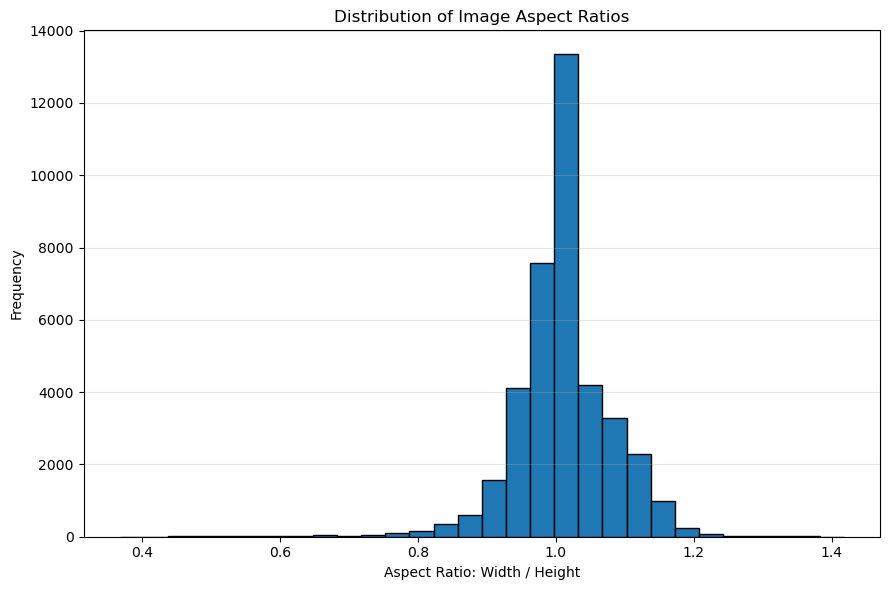

In [38]:
plt.figure(figsize=(9, 6))

plt.hist(train_csv["AspectRatio"], bins=30, edgecolor="black")

plt.xlabel("Aspect Ratio: Width / Height")
plt.ylabel("Frequency")
plt.title("Distribution of Image Aspect Ratios")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "aspect_ratio_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

#### 7. File Validation

The image paths are checked to identify missing, unreadable or corrupted files.

In [39]:
missing_training_images = []
corrupted_training_images = []

for relative_path in train_csv["Path"]:
    image_path = DATA_DIR / relative_path

    if not image_path.exists():
        missing_training_images.append(str(image_path))
        continue

    try:
        with Image.open(image_path) as image:
            image.verify()

    except (OSError, UnidentifiedImageError):
        corrupted_training_images.append(str(image_path))

print("Missing training images:", len(missing_training_images))
print("Corrupted training images:", len(corrupted_training_images))

Missing training images: 0
Corrupted training images: 0


In [40]:
missing_test_images = []
corrupted_test_images = []

for relative_path in test_csv["Path"]:
    image_path = DATA_DIR / relative_path

    if not image_path.exists():
        missing_test_images.append(str(image_path))
        continue

    try:
        with Image.open(image_path) as image:
            image.verify()

    except (OSError, UnidentifiedImageError):
        corrupted_test_images.append(str(image_path))

print("Missing test images:", len(missing_test_images))
print("Corrupted test images:", len(corrupted_test_images))

Missing test images: 0
Corrupted test images: 0


In [41]:
image_modes = {}

sample_for_mode_check = train_csv.sample(
    n=min(1000, len(train_csv)),
    random_state=42
)

for relative_path in sample_for_mode_check["Path"]:
    image_path = DATA_DIR / relative_path

    with Image.open(image_path) as image:
        mode = image.mode
        image_modes[mode] = image_modes.get(mode, 0) + 1

print("Image modes in sampled images:")
print(image_modes)

Image modes in sampled images:
{'RGB': 1000}


#### 8. Summary of Findings

- The GTSRB dataset contains 39,209 training images and 12,630 test images.
- The classification task contains 43 traffic sign classes.
- All class IDs from 0 to 42 are represented in both the training and test datasets.
- The class distribution is imbalanced because some classes contain substantially more images than others.
- The image widths and heights vary considerably.
- The original images therefore need to be resized to a consistent input size before training.
- Some traffic sign classes have similar shapes and colours, which may lead to classification errors.
- Image files were checked for missing or corrupted data.
- The next stage is to create stratified training and validation splits and define the preprocessing pipeline.

In [42]:
eda_summary = pd.DataFrame({
    "Statistic": [
        "Training images",
        "Test images",
        "Number of classes",
        "Minimum class size",
        "Maximum class size",
        "Mean class size",
        "Minimum image width",
        "Maximum image width",
        "Mean image width",
        "Minimum image height",
        "Maximum image height",
        "Mean image height",
        "Missing training images",
        "Corrupted training images",
        "Missing test images",
        "Corrupted test images"
    ],
    "Value": [
        len(train_csv),
        len(test_csv),
        number_of_classes,
        class_counts.min(),
        class_counts.max(),
        round(class_counts.mean(), 2),
        train_csv["Width"].min(),
        train_csv["Width"].max(),
        round(train_csv["Width"].mean(), 2),
        train_csv["Height"].min(),
        train_csv["Height"].max(),
        round(train_csv["Height"].mean(), 2),
        len(missing_training_images),
        len(corrupted_training_images),
        len(missing_test_images),
        len(corrupted_test_images)
    ]
})

display(eda_summary)

,Statistic,Value
0,Training images,39209.00
1,Test images,12630.00
2,Number of classes,43.00
3,Minimum class size,210.00
4,Maximum class size,2250.00
5,Mean class size,911.84
6,Minimum image width,25.00
7,Maximum image width,243.00
8,Mean image width,50.84
9,Minimum image height,25.00


In [43]:
eda_summary.to_csv(RESULTS_DIR / "eda_summary.csv", index=False)

class_distribution_df.to_csv(RESULTS_DIR / "class_distribution.csv", index=False)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.
